In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (roc_curve, roc_auc_score, precision_recall_curve,
                             classification_report, auc, f1_score, fbeta_score)
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from numpy import argmax

1. Повторите анализ из лабораторной работы, но с двумерными датасетами. Изобразите графически, как изменение порога влияет на расположение границы принятия решений.

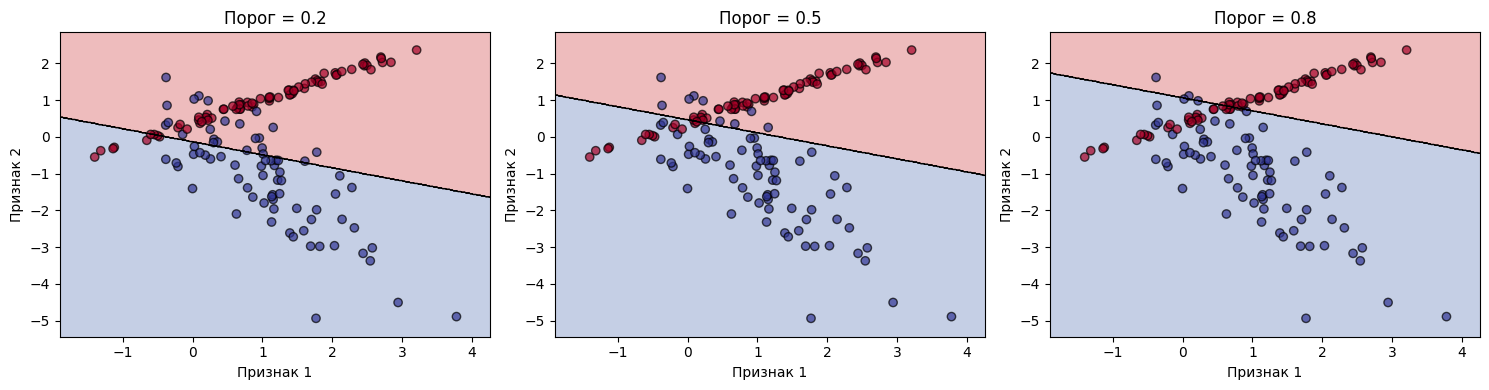

Вывод: При увеличении порога область положительного класса сужается,
модель становится более консервативной в предсказаниях класса 1.



In [ ]:
X, y = make_classification(n_samples=500, n_features=2, n_redundant=0,
                           n_clusters_per_class=1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred_proba = model.predict_proba(X_test)[:, 1]

def plot_decision_boundary(thresholds, X, y, model):
    fig, axes = plt.subplots(1, len(thresholds), figsize=(15, 4))

    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    Z_proba = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]

    for i, threshold in enumerate(thresholds):
        Z = (Z_proba >= threshold).astype(int)
        Z = Z.reshape(xx.shape)

        axes[i].contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu_r')
        axes[i].contour(xx, yy, Z, colors='black', linewidths=0.5)

        scatter = axes[i].scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu_r',
                                  edgecolors='black', alpha=0.7)

        axes[i].set_title(f'Порог = {threshold}')
        axes[i].set_xlabel('Признак 1')
        axes[i].set_ylabel('Признак 2')

    plt.tight_layout()
    plt.savefig('decision_boundary_thresholds.png', dpi=150)
    plt.show()

thresholds = [0.2, 0.5, 0.8]
plot_decision_boundary(thresholds, X_test, y_test, model)
print("Вывод: При увеличении порога область положительного класса сужается,")
print("модель становится более консервативной в предсказаниях класса 1.\n")

2. Повторите анализ на реальном датасете для бинарной классификации. Проинтерпретируйте результат, сделайте вывод.

Размер датасета: (569, 30)
Соотношение классов: 0=212, 1=357


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



ROC-AUC: 0.989
PR-AUC: 0.993


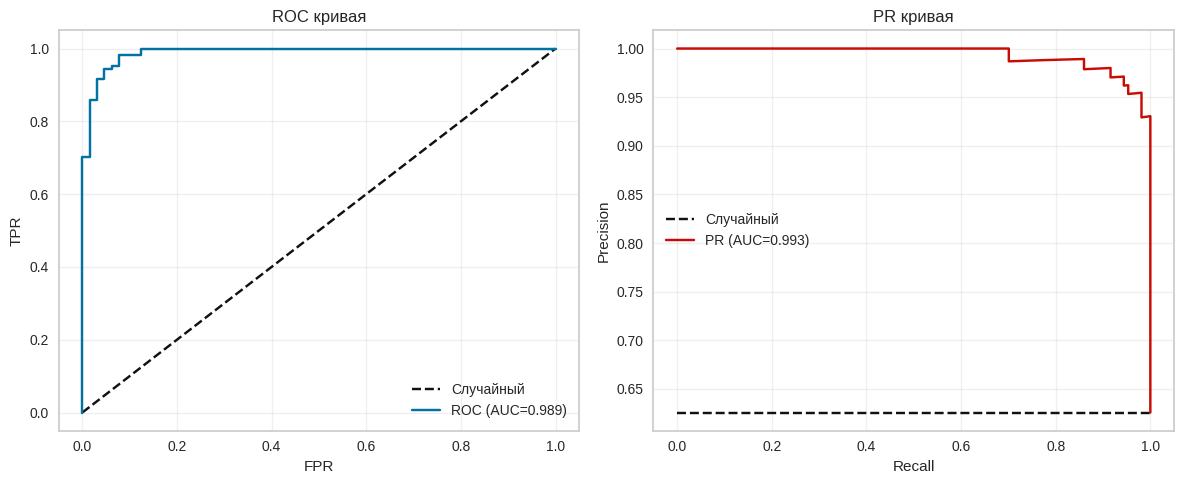

Графики сохранены в 'real_dataset_curves.png'
Вывод: Модель показывает отличные результаты на реальных данных,
PR-AUC близок к ROC-AUC, что говорит о сбалансированности классов.



In [ ]:
data = load_breast_cancer()
X, y = data.data, data.target
print(f"Размер датасета: {X.shape}")
print(f"Соотношение классов: 0={sum(y==0)}, 1={sum(y==1)}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
                                                    stratify=y, random_state=42)

model_real = LogisticRegression(max_iter=1000)
model_real.fit(X_train, y_train)
y_pred_proba_real = model_real.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_pred_proba_real)
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba_real)

roc_auc = roc_auc_score(y_test, y_pred_proba_real)
pr_auc = auc(recall, precision)

print(f"\nROC-AUC: {roc_auc:.3f}")
print(f"PR-AUC: {pr_auc:.3f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot([0, 1], [0, 1], 'k--', label='Случайный')
ax1.plot(fpr, tpr, 'b-', label=f'ROC (AUC={roc_auc:.3f})')
ax1.set_xlabel('FPR')
ax1.set_ylabel('TPR')
ax1.set_title('ROC кривая')
ax1.legend()
ax1.grid(True, alpha=0.3)

no_skill = sum(y_test==1) / len(y_test)
ax2.plot([0, 1], [no_skill, no_skill], 'k--', label='Случайный')
ax2.plot(recall, precision, 'r-', label=f'PR (AUC={pr_auc:.3f})')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('PR кривая')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('real_dataset_curves.png', dpi=150)
plt.show()

print("Графики сохранены в 'real_dataset_curves.png'")
print("Вывод: Модель показывает отличные результаты на реальных данных,")
print("PR-AUC близок к ROC-AUC, что говорит о сбалансированности классов.\n")

3. В задании по оптимизации порога используйте ROC и среднее геометрическое между TPR и FPR как критерий оптимизации.

Оптимальный порог по G-mean: 0.0617
Максимальный G-mean: 0.8406
TPR при этом пороге: 0.8193
FPR при этом пороге: 0.1376

Порог 0.5:
  TPR (Recall): 0.3012
  FPR: 0.0078
  G-mean: 0.5467

Порог 0.062:
  TPR (Recall): 0.8193
  FPR: 0.1376
  G-mean: 0.8406


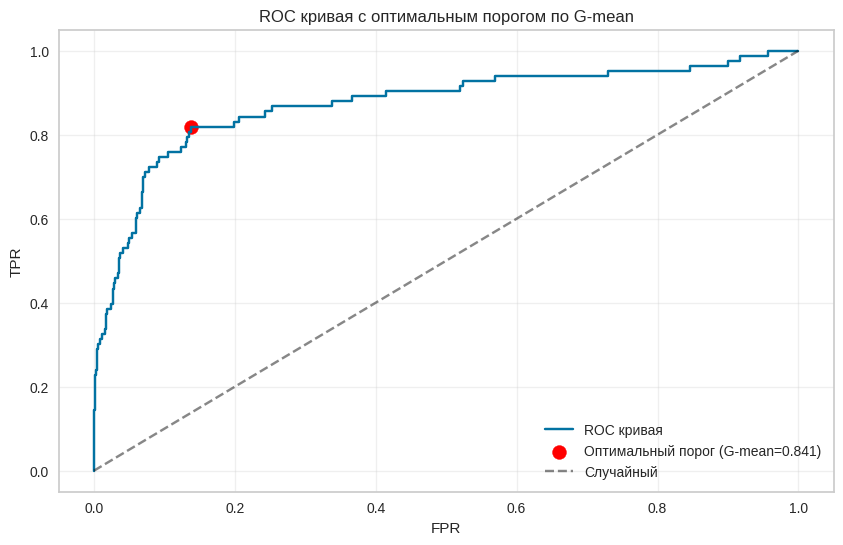

График сохранен в 'roc_optimal_threshold.png'



In [ ]:
X, y = make_classification(n_samples=5000, n_classes=2, weights=[0.95, 0.05],
                          random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
                                                    stratify=y, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)
y_pred_proba = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

gmean = np.sqrt(tpr * (1 - fpr))

ix = argmax(gmean)
best_threshold = thresholds[ix]
best_gmean = gmean[ix]

print(f"Оптимальный порог по G-mean: {best_threshold:.4f}")
print(f"Максимальный G-mean: {best_gmean:.4f}")
print(f"TPR при этом пороге: {tpr[ix]:.4f}")
print(f"FPR при этом пороге: {fpr[ix]:.4f}")

y_pred_default = (y_pred_proba >= 0.5).astype(int)
y_pred_optimal = (y_pred_proba >= best_threshold).astype(int)


for name, y_pred in [("Порог 0.5", y_pred_default),
                     (f"Порог {best_threshold:.3f}", y_pred_optimal)]:
    tn = np.sum((y_test == 0) & (y_pred == 0))
    fp = np.sum((y_test == 0) & (y_pred == 1))
    fn = np.sum((y_test == 1) & (y_pred == 0))
    tp = np.sum((y_test == 1) & (y_pred == 1))

    tpr_calc = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr_calc = fp / (fp + tn) if (fp + tn) > 0 else 0

    print(f"\n{name}:")
    print(f"  TPR (Recall): {tpr_calc:.4f}")
    print(f"  FPR: {fpr_calc:.4f}")
    print(f"  G-mean: {np.sqrt(tpr_calc * (1 - fpr_calc)):.4f}")

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, 'b-', label='ROC кривая')
plt.scatter(fpr[ix], tpr[ix], c='red', s=100, marker='o',
           label=f'Оптимальный порог (G-mean={best_gmean:.3f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Случайный')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC кривая с оптимальным порогом по G-mean')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('roc_optimal_threshold.png', dpi=150)
plt.show()
print("График сохранен в 'roc_optimal_threshold.png'\n")

4. При оптимизации порога по PR-кривой используйте другую F-метрику - сначала с преимуществом precision, а затем - с превалированием recall. Изобразите получившиеся пороги на графике. Проанализируйте метрики получившихся моделей.

Оптимальные пороги для разных F-метрик:
--------------------------------------------------
F1 (равновесие): порог=0.1190, метрика=0.4854
F2 (recall важнее): порог=0.1109, метрика=0.5984
F0.5 (precision важнее): порог=0.5734, метрика=0.5911


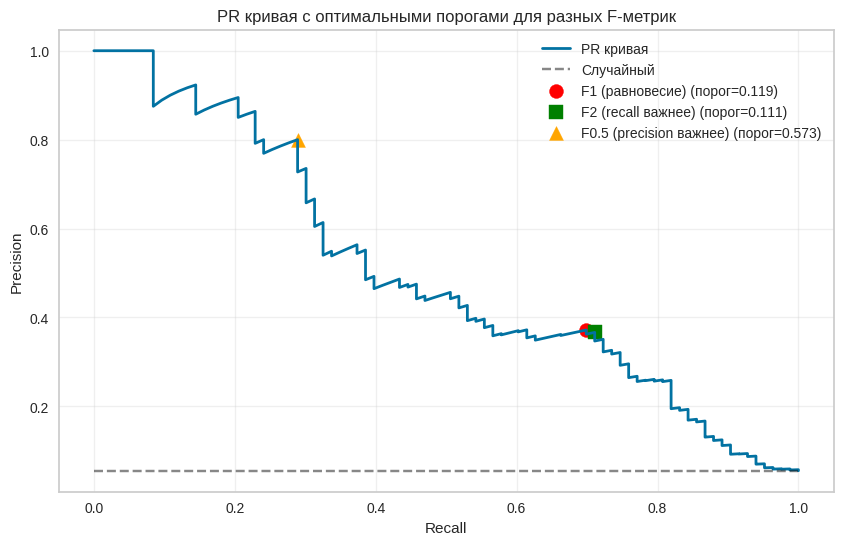


Сравнение моделей с разными порогами:

F1 (равновесие) (порог=0.1190):
  Precision: 0.3718
  Recall: 0.6988
  F1: 0.4854

F2 (recall важнее) (порог=0.1109):
  Precision: 0.3665
  Recall: 0.7108
  F1: 0.4836

F0.5 (precision важнее) (порог=0.5734):
  Precision: 0.8000
  Recall: 0.2892
  F1: 0.4248

Вывод: Выбор порога зависит от бизнес-задачи. Если важнее найти все
положительные объекты (recall), выбираем порог по F2. Если важнее
точность предсказаний (precision), выбираем порог по F0.5.



In [ ]:
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_pred_proba)
pr_thresholds = pr_thresholds[:-1]

f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-10)
f2_scores = (5 * precision[:-1] * recall[:-1]) / (4 * precision[:-1] + recall[:-1] + 1e-10)
f05_scores = (1.25 * precision[:-1] * recall[:-1]) / (0.25 * precision[:-1] + recall[:-1] + 1e-10)

ix_f1 = argmax(f1_scores)
ix_f2 = argmax(f2_scores)
ix_f05 = argmax(f05_scores)

thresholds_dict = {
    'F1 (равновесие)': (ix_f1, f1_scores[ix_f1]),
    'F2 (recall важнее)': (ix_f2, f2_scores[ix_f2]),
    'F0.5 (precision важнее)': (ix_f05, f05_scores[ix_f05])
}

print("Оптимальные пороги для разных F-метрик:")
print("-" * 50)
for name, (ix, score) in thresholds_dict.items():
    print(f"{name}: порог={pr_thresholds[ix]:.4f}, метрика={score:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(recall, precision, 'b-', linewidth=2, label='PR кривая')
no_skill = sum(y_test==1) / len(y_test)
plt.plot([0, 1], [no_skill, no_skill], 'k--', alpha=0.5, label='Случайный')

colors = ['red', 'green', 'orange']
markers = ['o', 's', '^']
for (name, (ix, score)), color, marker in zip(thresholds_dict.items(), colors, markers):
    plt.scatter(recall[ix], precision[ix], c=color, s=100,
               marker=marker, label=f'{name} (порог={pr_thresholds[ix]:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('PR кривая с оптимальными порогами для разных F-метрик')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('pr_optimal_fmetrics.png', dpi=150)
plt.show()

print("\n" + "="*40)
print("Сравнение моделей с разными порогами:")
print("="*40)

for name, (ix, _) in thresholds_dict.items():
    threshold = pr_thresholds[ix]
    y_pred = (y_pred_proba >= threshold).astype(int)

    tn = np.sum((y_test == 0) & (y_pred == 0))
    fp = np.sum((y_test == 0) & (y_pred == 1))
    fn = np.sum((y_test == 1) & (y_pred == 0))
    tp = np.sum((y_test == 1) & (y_pred == 1))

    precision_calc = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall_calc = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_calc = 2 * precision_calc * recall_calc / (precision_calc + recall_calc + 1e-10)

    print(f"\n{name} (порог={threshold:.4f}):")
    print(f"  Precision: {precision_calc:.4f}")
    print(f"  Recall: {recall_calc:.4f}")
    print(f"  F1: {f1_calc:.4f}")

print("\nВывод: Выбор порога зависит от бизнес-задачи. Если важнее найти все")
print("положительные объекты (recall), выбираем порог по F2. Если важнее")
print("точность предсказаний (precision), выбираем порог по F0.5.\n")

5. Постройте классификационные кривые для задачи множественной классификации. Проинтерпретируйте результат.

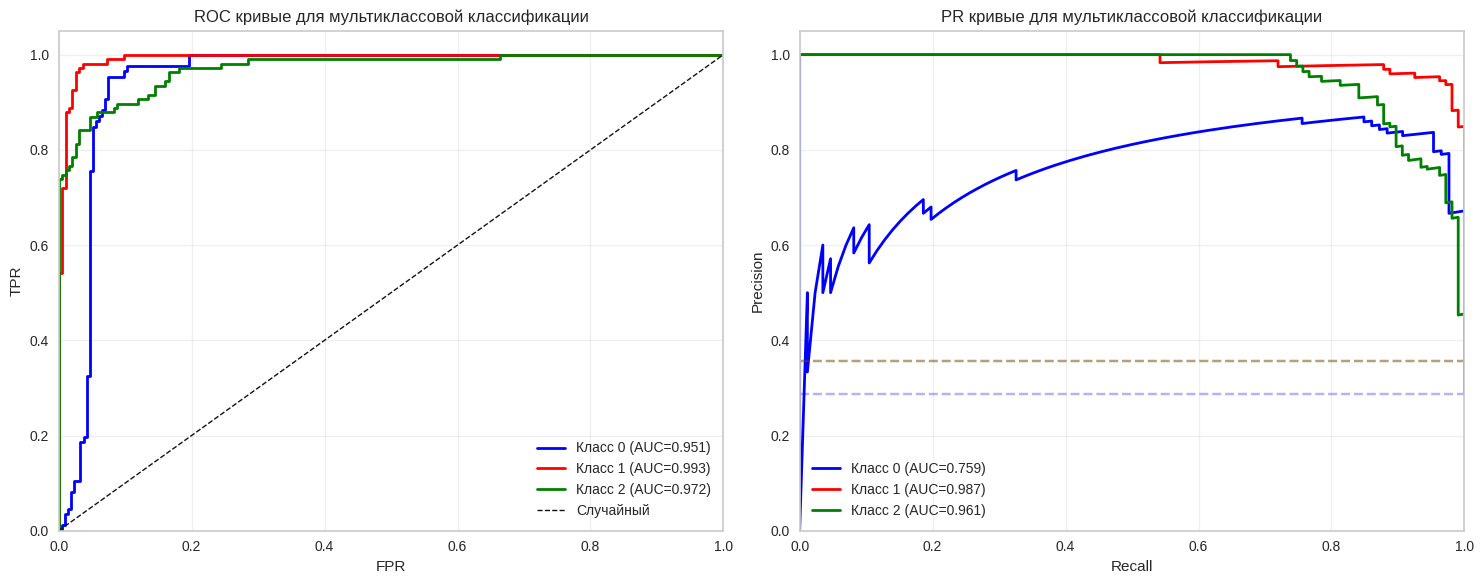

Графики сохранены в 'multiclass_curves.png'

Метрики по классам:
----------------------------------------
Класс 0: ROC-AUC=0.951, PR-AUC=0.759
Класс 1: ROC-AUC=0.993, PR-AUC=0.987
Класс 2: ROC-AUC=0.972, PR-AUC=0.961

Вывод: В многоклассовой задаче можно оценивать качество модели
по каждому классу отдельно. PR-AUC лучше подходит для несбалансированных
классов, показывая более реалистичную картину.



In [ ]:
X, y = make_classification(n_samples=1000, n_classes=3, n_features=20,
                          n_informative=5, n_clusters_per_class=1,
                          random_state=42)

y_bin = label_binarize(y, classes=[0, 1, 2])
n_classes = y_bin.shape[1]

X_train, X_test, y_train, y_test = train_test_split(X, y_bin, test_size=0.3, random_state=42)

model = OneVsRestClassifier(LogisticRegression(max_iter=1000))
model.fit(X_train, y_train)
y_score = model.predict_proba(X_test)

fpr = dict()
tpr = dict()
roc_auc = dict()
precision = dict()
recall = dict()
pr_auc = dict()

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
colors = ['blue', 'red', 'green']
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_score[:, i])
    roc_auc[i] = roc_auc_score(y_test[:, i], y_score[:, i])
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=2,
             label=f'Класс {i} (AUC={roc_auc[i]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Случайный')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC кривые для мультиклассовой классификации')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
for i in range(n_classes):
    precision[i], recall[i], _ = precision_recall_curve(y_test[:, i], y_score[:, i])
    pr_auc[i] = auc(recall[i], precision[i])
    plt.plot(recall[i], precision[i], color=colors[i], lw=2,
             label=f'Класс {i} (AUC={pr_auc[i]:.3f})')

for i in range(n_classes):
    no_skill = sum(y_test[:, i]) / len(y_test[:, i])
    plt.plot([0, 1], [no_skill, no_skill], '--', color=colors[i], alpha=0.3)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('PR кривые для мультиклассовой классификации')
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('multiclass_curves.png', dpi=150)
plt.show()

print("Графики сохранены в 'multiclass_curves.png'")
print("\nМетрики по классам:")
print("-" * 40)
for i in range(n_classes):
    print(f"Класс {i}: ROC-AUC={roc_auc[i]:.3f}, PR-AUC={pr_auc[i]:.3f}")

print("\nВывод: В многоклассовой задаче можно оценивать качество модели")
print("по каждому классу отдельно. PR-AUC лучше подходит для несбалансированных")
print("классов, показывая более реалистичную картину.\n")